<a href="https://colab.research.google.com/github/sheriannmclarty/DATA620_WebAnalytics_SheriannMc/blob/main/assignments/Davis%2C%20Gardner%20%26%20Gardner%20(1941)%20%C2%B7%20Deep%20South.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA 620 – Web Analytics
**Author:** Sheriann McLarty

**GitHub:** https://github.com/sheriannmclarty/DATA620_WebAnalytics_SheriannMc

## Assignment: Davis Southern Women Network Analysis

**Dataset:** Davis Southern Women Social Events (1941)  
**Description:** A bipartite graph of 18 Southern women and their attendance at 14 social events.  
**Reference:** Davis, A., Gardner, B.B., & Gardner, M.R. (1941). *Deep South*. Chicago: University of Chicago Press.
---

### Research Questions
1. What can we infer about the **relationships between the women**?
2. What can we infer about the **relationships between the social events**?

---

### Visual Encoding Key — consistent across all plots

| Element | Meaning |
|---|---|
| **Teal** nodes / bars | Women |
| **Amber** nodes / bars | Social events |
| **Node size** | Raw degree in the bipartite graph; weighted degree (sum of edge weights) in projected graphs |
| **Edge width + opacity** | Relationship strength in projected networks (shared events or shared women) |
| **Cell color intensity** | Relative centrality magnitude (normalized 0–1 per measure) |

## 1. Setup & Imports

In [15]:
import networkx as nx
import networkx.algorithms.bipartite as bipartite
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Global style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#DDDDDD',
    'axes.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlepad':     14,
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'xtick.color':       '#666666',
    'ytick.color':       '#666666',
    'text.color':        '#222222',
    'savefig.dpi':       180,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

# ── Shared palette — used everywhere, no cmaps outside this block ─────────────
C_WOMEN    = '#2A6B7C'   # deep teal      — all women visuals
C_EVENTS   = '#C4692A'   # burnt amber    — all event visuals
C_EDGE     = '#AAAAAA'   # neutral gray   — edges
C_G1       = '#1A4F5E'   # dark teal      — women community 1
C_G2       = '#8B3A12'   # dark amber     — women community 2
C_EG1      = '#C4692A'   # medium amber   — events community 1
C_EG2      = '#1E6B7C'   # medium teal    — events community 2

# Custom sequential colormaps derived from palette (no Matplotlib defaults)
CMAP_WOMEN  = mcolors.LinearSegmentedColormap.from_list('teal_seq',  ['#EAF4F7', '#2A6B7C'])
CMAP_EVENTS = mcolors.LinearSegmentedColormap.from_list('amber_seq', ['#FDF0E8', '#C4692A'])

print('NetworkX version:', nx.__version__)
print('All imports successful.')

NetworkX version: 3.6.1
All imports successful.


## 2. Load Dataset

The Davis Southern Women dataset is built into NetworkX — a **bipartite graph** with two node sets:
- **Top nodes (bipartite=0):** 18 women
- **Bottom nodes (bipartite=1):** 14 social events

An edge connects a woman to each event she attended.

In [16]:
G = nx.davis_southern_women_graph()

# Separate node types
women  = [n for n, d in G.nodes(data=True) if d.get('bipartite') == 0]
events = [n for n, d in G.nodes(data=True) if d.get('bipartite') == 1]

print(f'Total nodes : {G.number_of_nodes()}')
print(f'Total edges : {G.number_of_edges()}')
print(f'Women  ({len(women)}): {women}')
print(f'Events ({len(events)}): {events}')
print(f'Is bipartite: {bipartite.is_bipartite(G)}')

Total nodes : 32
Total edges : 89
Women  (18): ['Evelyn Jefferson', 'Laura Mandeville', 'Theresa Anderson', 'Brenda Rogers', 'Charlotte McDowd', 'Frances Anderson', 'Eleanor Nye', 'Pearl Oglethorpe', 'Ruth DeSand', 'Verne Sanderson', 'Myra Liddel', 'Katherina Rogers', 'Sylvia Avondale', 'Nora Fayette', 'Helen Lloyd', 'Dorothy Murchison', 'Olivia Carleton', 'Flora Price']
Events (14): ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14']
Is bipartite: True


Before getting into projections and centrality, I wanted to look at the basic attendance patterns first. That gives a clearer starting point for understanding who was most active and which events were the most attended.

## 3. Exploratory Analysis

*Encoding: bar length = count; color intensity = rank (darker = higher count)*

In [17]:
# Sort by degree — ordering is design, not an afterthought
women_degree  = {w: G.degree(w) for w in women}
events_degree = {e: G.degree(e) for e in events}

df_women  = pd.DataFrame.from_dict(women_degree,  orient='index', columns=['events_attended']).sort_values('events_attended', ascending=False)
df_events = pd.DataFrame.from_dict(events_degree, orient='index', columns=['women_attended']).sort_values('women_attended',  ascending=False)

print('=== Women – Events Attended (sorted) ===')
print(df_women.to_string())
print()
print('=== Events – Women Attended (sorted) ===')
print(df_events.to_string())

=== Women – Events Attended (sorted) ===
                   events_attended
Evelyn Jefferson                 8
Theresa Anderson                 8
Nora Fayette                     8
Laura Mandeville                 7
Sylvia Avondale                  7
Brenda Rogers                    7
Katherina Rogers                 6
Helen Lloyd                      5
Charlotte McDowd                 4
Frances Anderson                 4
Myra Liddel                      4
Verne Sanderson                  4
Ruth DeSand                      4
Eleanor Nye                      4
Pearl Oglethorpe                 3
Dorothy Murchison                2
Olivia Carleton                  2
Flora Price                      2

=== Events – Women Attended (sorted) ===
     women_attended
E8               14
E9               12
E7               10
E5                8
E6                8
E3                6
E12               6
E10               5
E4                4
E11               4
E1                3
E2          

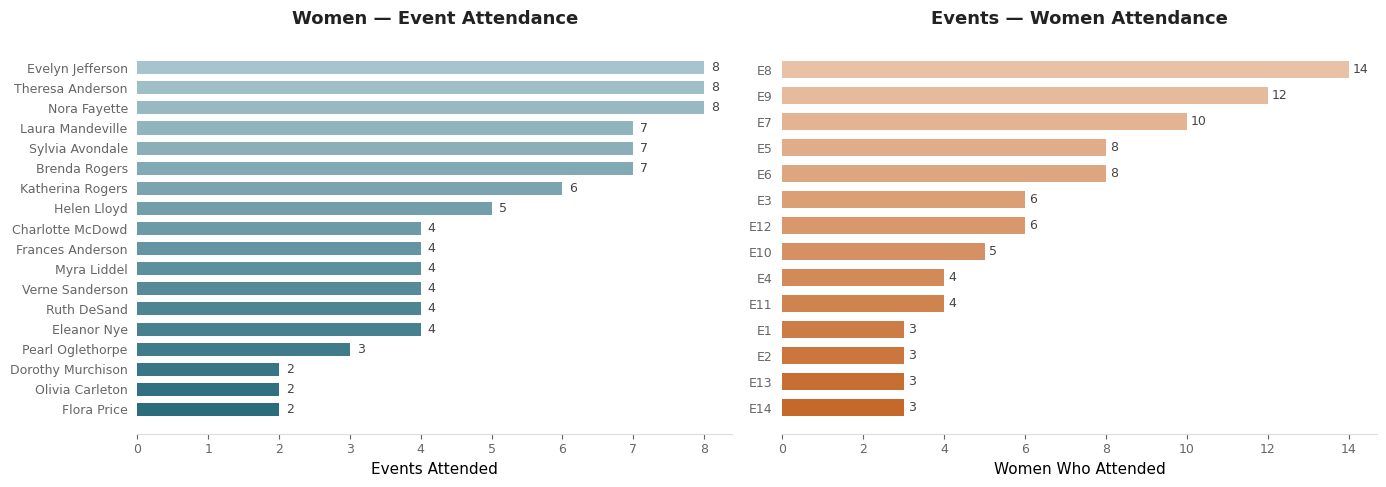

Saved: degree_distributions.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Women bars — teal gradient
ax = axes[0]
n_w = len(df_women)
colors_w = [CMAP_WOMEN(0.35 + 0.65 * (i / (n_w - 1))) for i in range(n_w)]
bars = ax.barh(df_women.index, df_women['events_attended'], color=colors_w, height=0.65)
ax.set_xlabel('Events Attended')
ax.set_title('Women — Event Attendance', fontweight='bold')
ax.invert_yaxis()
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)
for bar, val in zip(bars, df_women['events_attended']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9, color='#444444')

# Events bars — amber gradient
ax2 = axes[1]
n_e = len(df_events)
colors_e = [CMAP_EVENTS(0.35 + 0.65 * (i / (n_e - 1))) for i in range(n_e)]
bars2 = ax2.barh(df_events.index, df_events['women_attended'], color=colors_e, height=0.65)
ax2.set_xlabel('Women Who Attended')
ax2.set_title('Events — Women Attendance', fontweight='bold')
ax2.invert_yaxis()
ax2.spines['left'].set_visible(False)
ax2.tick_params(left=False)
for bar, val in zip(bars2, df_events['women_attended']):
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9, color='#444444')

plt.tight_layout()
plt.savefig('degree_distributions.png')
plt.show()
print('Saved: degree_distributions.png')

I kept the bipartite graph as the first network view because it shows the data in its original form. That felt like the best way to understand the structure before creating projected ties.

## 4. Bipartite Graph Visualization

*Encoding: node size = events attended (women) / women attending (events); edge opacity = 18% to keep 89 edges readable*

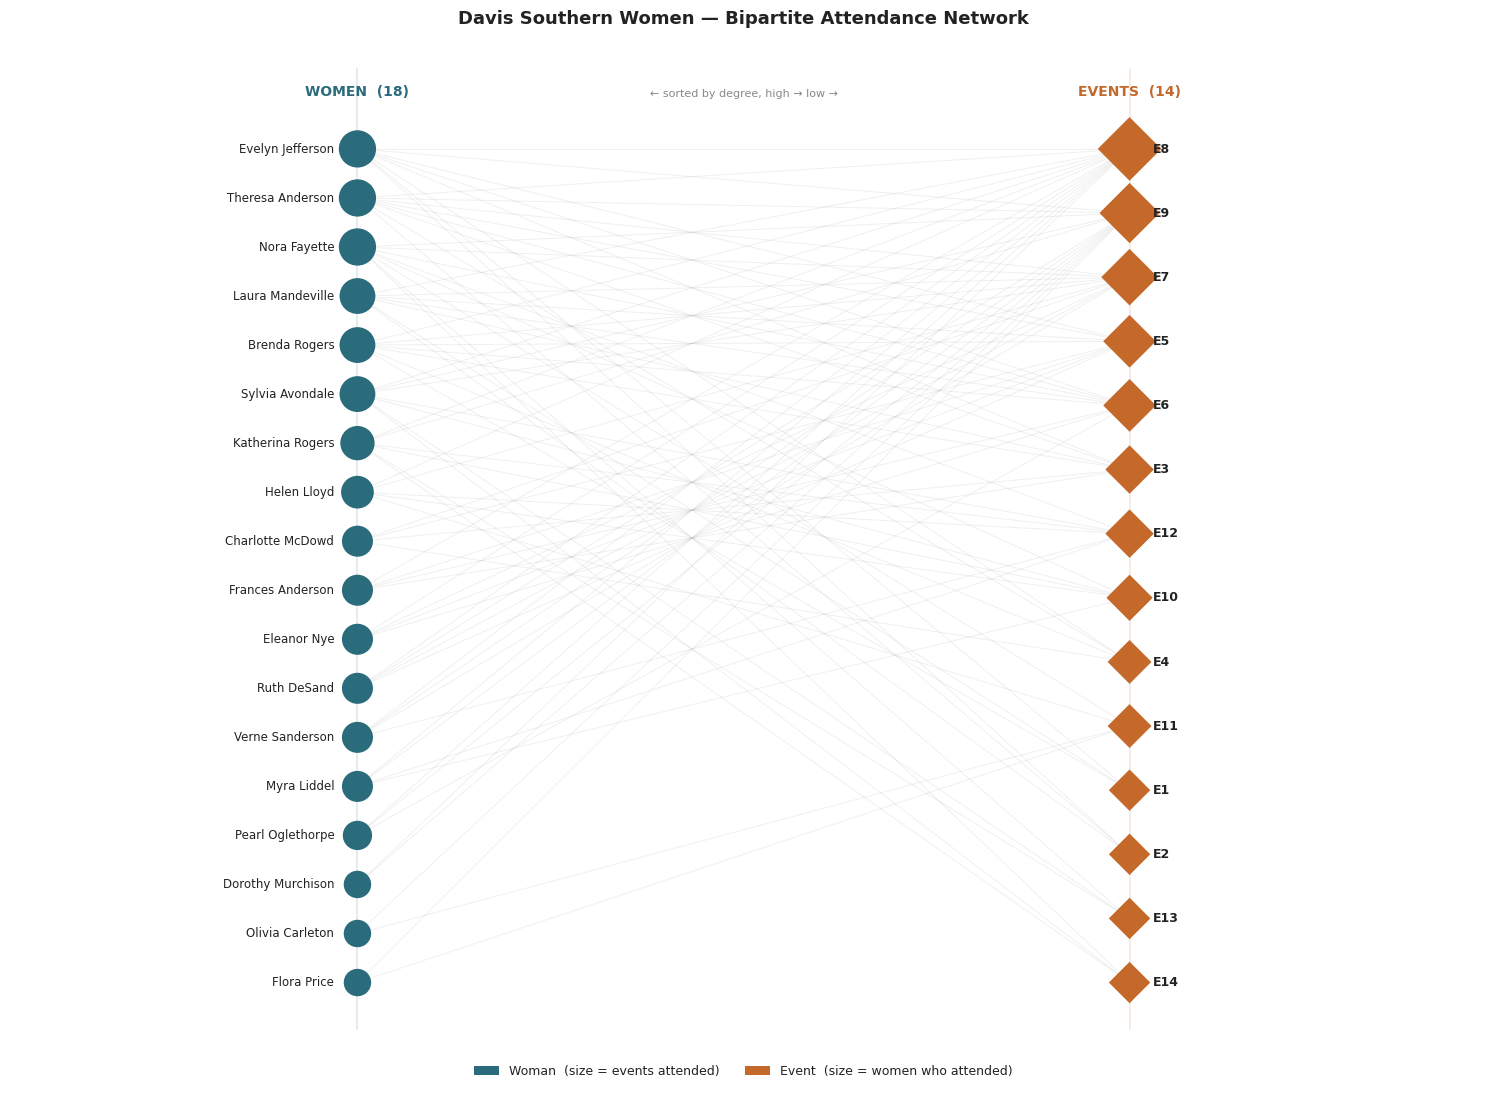

Saved: bipartite_graph.png


In [19]:
# Order nodes by degree so the busiest sit at top of each column
women_sorted  = sorted(women,  key=lambda w: G.degree(w), reverse=True)
events_sorted = sorted(events, key=lambda e: G.degree(e), reverse=True)

fig, ax = plt.subplots(figsize=(15, 11))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

pos = {}
for i, w in enumerate(women_sorted):
    pos[w] = (0.0, 1.0 - i / (len(women_sorted) - 1))
for i, e in enumerate(events_sorted):
    pos[e] = (1.0, 1.0 - i / (len(events_sorted) - 1))

nx.draw_networkx_edges(G, pos, edge_color=C_EDGE, alpha=0.18, width=0.7, ax=ax)

# Node size encodes degree
w_sizes = [280 + 55 * G.degree(w) for w in women_sorted]
e_sizes = [280 + 55 * G.degree(e) for e in events_sorted]

nx.draw_networkx_nodes(G, pos, nodelist=women_sorted,
                       node_color=C_WOMEN, node_size=w_sizes,
                       alpha=1.0, linewidths=0, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=events_sorted,
                       node_color=C_EVENTS, node_size=e_sizes,
                       node_shape='D', alpha=1.0, linewidths=0, ax=ax)

# Labels offset outside nodes
for w in women_sorted:
    x, y = pos[w]
    ax.text(x - 0.03, y, w, ha='right', va='center', fontsize=8.5, color='#222222')
for e in events_sorted:
    x, y = pos[e]
    ax.text(x + 0.03, y, e, ha='left', va='center', fontsize=9, color='#222222', fontweight='bold')

ax.text(0.0, 1.06, 'WOMEN  (18)',  ha='center', va='bottom', fontsize=10, fontweight='bold', color=C_WOMEN)
ax.text(1.0, 1.06, 'EVENTS  (14)', ha='center', va='bottom', fontsize=10, fontweight='bold', color=C_EVENTS)
ax.text(0.5, 1.06, '← sorted by degree, high → low →', ha='center', va='bottom', fontsize=8, color='#888888')

ax.axvline(0.0, color=C_WOMEN,  alpha=0.15, linewidth=1.2, ymin=0.02, ymax=0.98)
ax.axvline(1.0, color=C_EVENTS, alpha=0.15, linewidth=1.2, ymin=0.02, ymax=0.98)

ax.legend(handles=[
    Patch(facecolor=C_WOMEN,  label='Woman  (size = events attended)'),
    Patch(facecolor=C_EVENTS, label='Event  (size = women who attended)'),
], loc='lower center', bbox_to_anchor=(0.5, -0.04), ncol=2,
   frameon=False, fontsize=9)

ax.set_title('Davis Southern Women — Bipartite Attendance Network', pad=18)
ax.set_xlim(-0.45, 1.45)
ax.set_ylim(-0.08, 1.12)
ax.axis('off')
plt.tight_layout()
plt.savefig('bipartite_graph.png')
plt.show()
print('Saved: bipartite_graph.png')

### WHY PROJECTION

Projection collapses the bipartite graph onto one node type. We project onto women to answer RQ1 (relationships between women) and onto events to answer RQ2 (relationships between events). We use `weighted_projected_graph` rather than a simple projection because the weight (number of co-attended events) carries analytic meaning — a stronger tie between two women, not just a binary connection. The weight is then used consistently to size nodes, scale edges, and compute centrality.

Since the main questions are about relationships among the women and among the events, projection was the next logical step. It turns shared attendance into direct relationships that can be analyzed more clearly.

## 5. Projected Networks

*Encoding: node size = weighted degree (sum of edge weights); edge width + opacity = co-attendance strength*

In [20]:
W = bipartite.weighted_projected_graph(G, women)
E = bipartite.weighted_projected_graph(G, events)

print(f'Women projection  – nodes: {W.number_of_nodes()}, edges: {W.number_of_edges()}')
print(f'Events projection – nodes: {E.number_of_nodes()}, edges: {E.number_of_edges()}')

print('\nTop 10 Women Pairs by Shared Events:')
for u, v, d in sorted(W.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:10]:
    print(f'  {u:20s} & {v:20s}  →  {d["weight"]} shared events')

print('\nTop 10 Event Pairs by Shared Women:')
for u, v, d in sorted(E.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:10]:
    print(f'  {u:6s} & {v:6s}  →  {d["weight"]} shared women')

Women projection  – nodes: 18, edges: 139
Events projection – nodes: 14, edges: 66

Top 10 Women Pairs by Shared Events:
  Evelyn Jefferson     & Theresa Anderson      →  7 shared events
  Evelyn Jefferson     & Brenda Rogers         →  6 shared events
  Evelyn Jefferson     & Laura Mandeville      →  6 shared events
  Laura Mandeville     & Theresa Anderson      →  6 shared events
  Laura Mandeville     & Brenda Rogers         →  6 shared events
  Theresa Anderson     & Brenda Rogers         →  6 shared events
  Katherina Rogers     & Sylvia Avondale       →  6 shared events
  Sylvia Avondale      & Nora Fayette          →  6 shared events
  Katherina Rogers     & Nora Fayette          →  5 shared events
  Evelyn Jefferson     & Frances Anderson      →  4 shared events

Top 10 Event Pairs by Shared Women:
  E8     & E9      →  9 shared women
  E7     & E8      →  8 shared women
  E5     & E8      →  7 shared women
  E6     & E8      →  7 shared women
  E3     & E5      →  6 shared wom

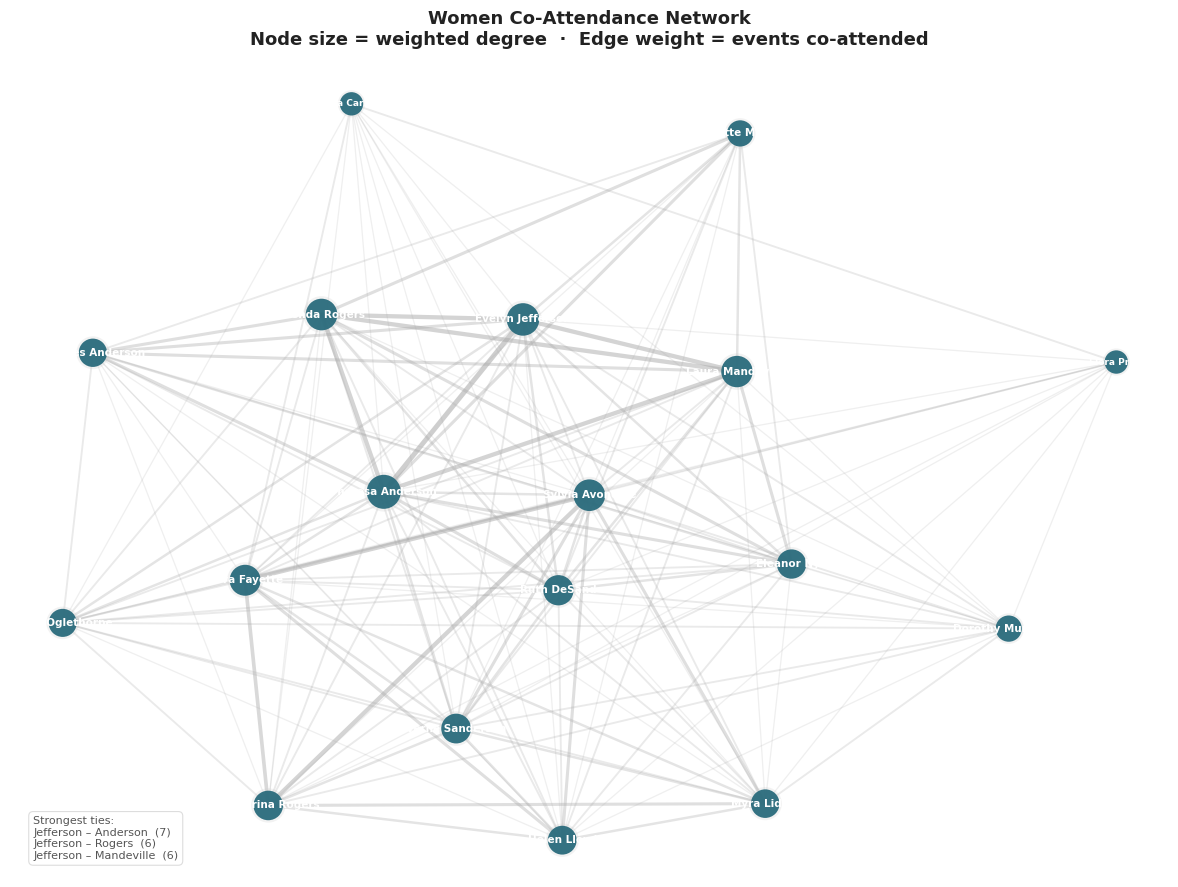

Saved: women_projection.png


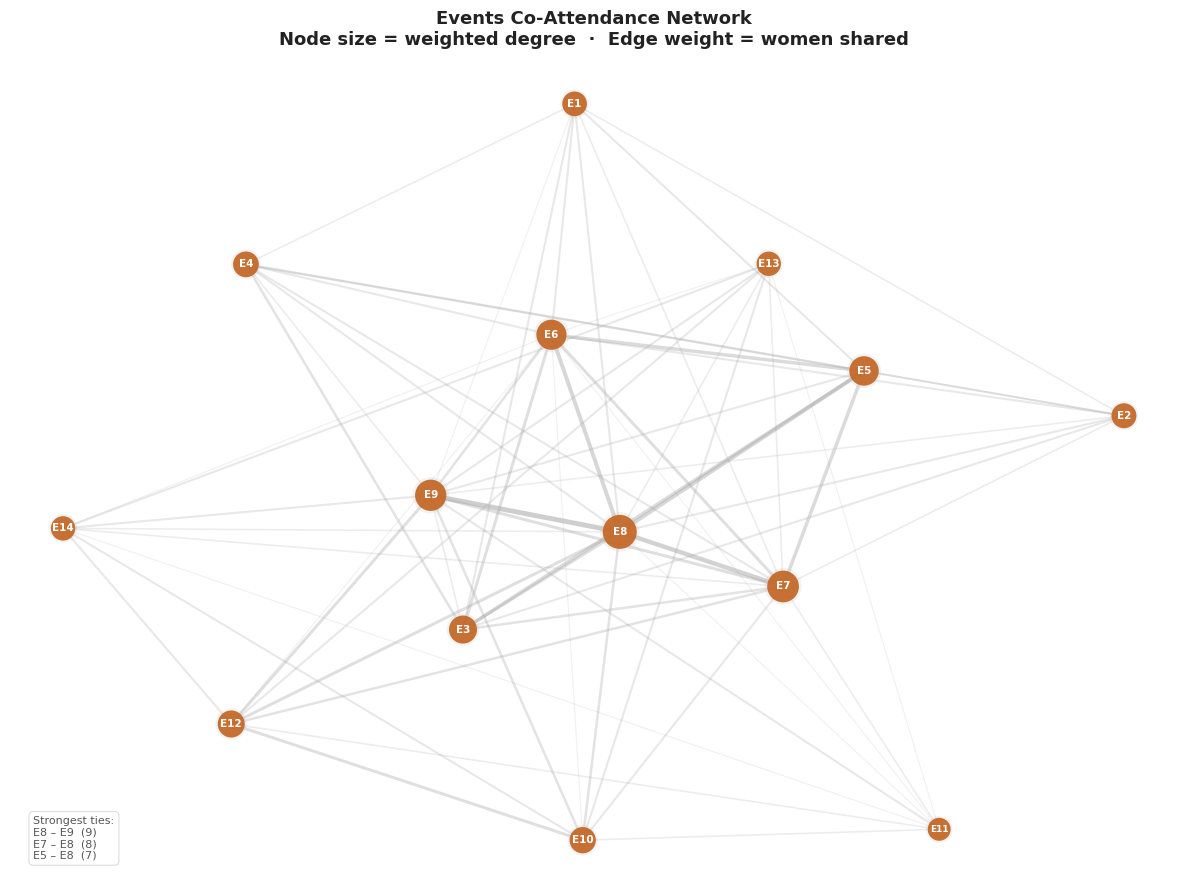

Saved: events_projection.png


In [21]:
def draw_projection_clean(G_proj, title, node_color, filename):
    """Projection network plot. Node size = weighted degree. Edge width+alpha = weight."""
    weights = np.array([d['weight'] for _, _, d in G_proj.edges(data=True)])
    max_w   = weights.max() if len(weights) else 1
    w_norm  = weights / max_w

    wdeg   = dict(G_proj.degree(weight='weight'))
    max_wd = max(wdeg.values())

    pos = nx.spring_layout(G_proj, weight='weight', seed=42, k=3.2)

    fig, ax = plt.subplots(figsize=(12, 9))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    for (u, v, d), wn in zip(G_proj.edges(data=True), w_norm):
        x0, y0 = pos[u]; x1, y1 = pos[v]
        ax.plot([x0, x1], [y0, y1],
                color=C_EDGE, linewidth=0.5 + 3.0 * wn,
                alpha=0.12 + 0.45 * wn, solid_capstyle='round')

    node_list  = list(G_proj.nodes())
    node_sizes = [180 + 420 * (wdeg[n] / max_wd) for n in node_list]

    # Shadow then fill (draw order replaces zorder)
    nx.draw_networkx_nodes(G_proj, pos, nodelist=node_list,
                           node_size=[s * 1.35 for s in node_sizes],
                           node_color='#CCCCCC', alpha=0.25, linewidths=0, ax=ax)
    nx.draw_networkx_nodes(G_proj, pos, nodelist=node_list,
                           node_size=node_sizes, node_color=node_color,
                           alpha=0.95, linewidths=0, ax=ax)

    for node in node_list:
        x, y = pos[node]
        size_pt = 180 + 420 * (wdeg[node] / max_wd)
        ax.text(x, y, node, ha='center', va='center',
                fontsize=7.5 if size_pt > 300 else 6.5,
                fontweight='bold', color='white')

    top3 = sorted(G_proj.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:3]
    note = 'Strongest ties:\n' + '\n'.join(
        f"{u.split()[-1] if ' ' in u else u} – {v.split()[-1] if ' ' in v else v}  ({d['weight']})"
        for u, v, d in top3
    )
    ax.text(0.02, 0.02, note, transform=ax.transAxes, fontsize=8, color='#555555',
            va='bottom', ha='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='#DDDDDD', linewidth=0.8))

    ax.set_title(title, pad=16)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    print(f'Saved: {filename}')


draw_projection_clean(W,
    'Women Co-Attendance Network\nNode size = weighted degree  ·  Edge weight = events co-attended',
    C_WOMEN, 'women_projection.png')

draw_projection_clean(E,
    'Events Co-Attendance Network\nNode size = weighted degree  ·  Edge weight = women shared',
    C_EVENTS, 'events_projection.png')

I used centrality here to go beyond just "who showed up the most." It helps identify who sits in the most important positions in the network and which nodes help connect the rest.

## 6. Centrality Analysis

*Encoding: cell color intensity = normalized centrality score (0–1 per column); values printed inside cells*

**Note on weighted centrality:** Edge weight in the projection = number of shared events/women — a stronger tie, not a distance. For path-based measures (betweenness, closeness), weight must be converted to distance (inverse weight) so that stronger ties = shorter paths. Degree and eigenvector centrality use raw weights directly.

In [22]:
# Add distance = 1/weight for path-based centrality measures
for u, v, d in W.edges(data=True):
    d['distance'] = 1.0 / d['weight']
for u, v, d in E.edges(data=True):
    d['distance'] = 1.0 / d['weight']

# Women centrality
# Degree + Eigenvector: use raw weight (stronger tie = more influence)
# Betweenness + Closeness: use distance (stronger tie = shorter path)
degree_c  = nx.degree_centrality(W)
between_c = nx.betweenness_centrality(W, weight='distance')
close_c   = nx.closeness_centrality(W,   distance='distance')
eigen_c   = nx.eigenvector_centrality(W, weight='weight', max_iter=1000)

df_centrality_women = pd.DataFrame({
    'Degree': degree_c, 'Betweenness': between_c,
    'Closeness': close_c, 'Eigenvector': eigen_c
}).round(4).sort_values('Eigenvector', ascending=False)
df_centrality_women.index.name = 'Woman'

print('=== Centrality Measures – Women Projection ===')
print(df_centrality_women.to_string())

print('\nTop 3 by Betweenness (brokers):')
print(df_centrality_women['Betweenness'].nlargest(3).to_string())
print('\nTop 3 by Eigenvector (prestige):')
print(df_centrality_women['Eigenvector'].nlargest(3).to_string())

=== Centrality Measures – Women Projection ===
                   Degree  Betweenness  Closeness  Eigenvector
Woman                                                         
Theresa Anderson   1.0000       0.2610     2.6250       0.3536
Evelyn Jefferson   1.0000       0.0319     2.2418       0.3185
Brenda Rogers      0.8824       0.0110     2.1031       0.3042
Laura Mandeville   0.8824       0.0025     2.0816       0.3004
Sylvia Avondale    1.0000       0.0631     2.3526       0.2729
Nora Fayette       1.0000       0.1973     2.2892       0.2533
Ruth DeSand        1.0000       0.0000     2.0606       0.2485
Eleanor Nye        0.8824       0.0000     1.9065       0.2390
Verne Sanderson    1.0000       0.0000     2.1093       0.2307
Katherina Rogers   0.9412       0.0000     1.9578       0.2220
Frances Anderson   0.8824       0.0000     1.7436       0.2180
Helen Lloyd        1.0000       0.0000     1.8594       0.2069
Myra Liddel        0.9412       0.0000     1.8378       0.1977
Pearl Og

In [23]:
# Events centrality
degree_ce  = nx.degree_centrality(E)
between_ce = nx.betweenness_centrality(E, weight='distance')
close_ce   = nx.closeness_centrality(E,   distance='distance')
eigen_ce   = nx.eigenvector_centrality(E, weight='weight', max_iter=1000)

df_centrality_events = pd.DataFrame({
    'Degree': degree_ce, 'Betweenness': between_ce,
    'Closeness': close_ce, 'Eigenvector': eigen_ce
}).round(4).sort_values('Eigenvector', ascending=False)
df_centrality_events.index.name = 'Event'

print('=== Centrality Measures – Events Projection ===')
print(df_centrality_events.to_string())

print('\nTop 3 Events by Betweenness (bridge events):')
print(df_centrality_events['Betweenness'].nlargest(3).to_string())
print('\nTop 3 Events by Eigenvector (most central):')
print(df_centrality_events['Eigenvector'].nlargest(3).to_string())

=== Centrality Measures – Events Projection ===
       Degree  Betweenness  Closeness  Eigenvector
Event                                             
E8     1.0000       0.4359     3.7088       0.4526
E7     1.0000       0.0000     3.0409       0.3770
E9     1.0000       0.2949     3.3252       0.3517
E6     1.0000       0.0000     2.9245       0.3389
E5     0.6154       0.0000     3.0155       0.3327
E3     0.6154       0.0000     2.6928       0.2769
E12    0.6154       0.0000     2.7646       0.2156
E4     0.6154       0.0000     2.0330       0.2030
E10    0.6154       0.0000     2.5069       0.1869
E2     0.6154       0.0000     1.9443       0.1771
E1     0.6154       0.0000     1.9443       0.1679
E13    0.6154       0.0000     1.8328       0.1316
E14    0.6154       0.0000     1.8328       0.1316
E11    0.6154       0.0000     1.6754       0.1015

Top 3 Events by Betweenness (bridge events):
Event
E8    0.4359
E9    0.2949
E7    0.0000

Top 3 Events by Eigenvector (most central):


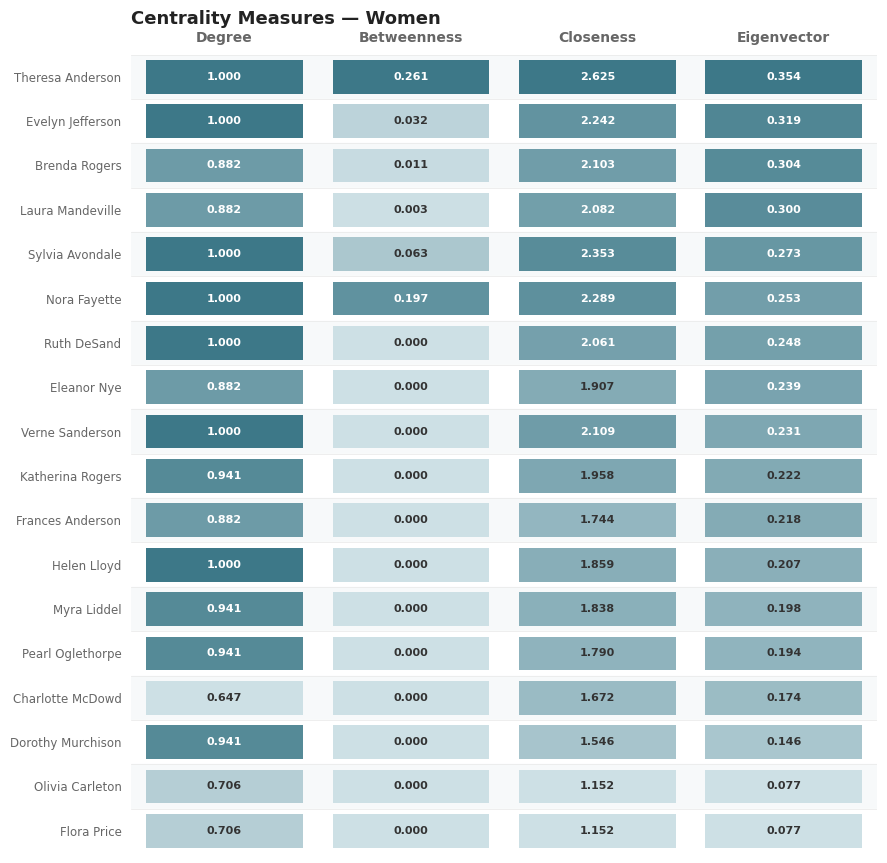

Saved: centrality_women.png


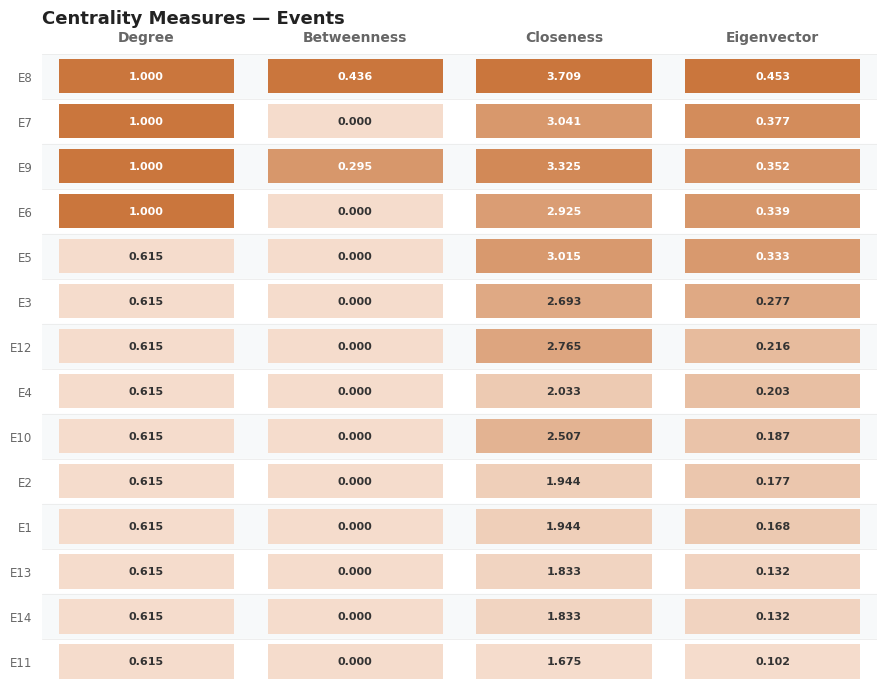

Saved: centrality_events.png


In [24]:
def draw_centrality_clean(df, title, cmap, filename):
    """Centrality heatmap. Cell color = normalized score. Values printed inside."""
    df_norm  = (df - df.min()) / (df.max() - df.min())
    n_rows, n_cols = df.shape
    fig_h = max(5, n_rows * 0.42 + 1.2)

    fig, ax = plt.subplots(figsize=(9, fig_h))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    for row_i, (node, row) in enumerate(df_norm.iterrows()):
        bg = '#F7F9FA' if row_i % 2 == 0 else 'white'
        ax.add_patch(plt.Rectangle((-0.5, row_i - 0.5), n_cols, 1, color=bg))
        for col_j, (_, val) in enumerate(row.items()):
            rgba = cmap(0.15 + 0.75 * val)
            ax.add_patch(plt.Rectangle(
                (col_j - 0.42, row_i - 0.38), 0.84, 0.76,
                color=rgba, linewidth=0
            ))
            txt_color = 'white' if val > 0.55 else '#333333'
            ax.text(col_j, row_i, f'{df.iloc[row_i, col_j]:.3f}',
                    ha='center', va='center',
                    fontsize=8, color=txt_color, fontweight='bold')

    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(df.index, fontsize=8.5)
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(df.columns, fontsize=10, fontweight='bold')
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')

    for y in np.arange(-0.5, n_rows, 1):
        ax.axhline(y, color='#E8E8E8', linewidth=0.5)

    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(-0.5, n_rows - 0.5)
    ax.invert_yaxis()
    for spine in ['left', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)
    ax.spines['top'].set_color('#CCCCCC')
    ax.tick_params(left=False, top=False)
    ax.set_title(title, pad=22, loc='left')
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    print(f'Saved: {filename}')


draw_centrality_clean(df_centrality_women, 'Centrality Measures — Women',
                      CMAP_WOMEN, 'centrality_women.png')

draw_centrality_clean(df_centrality_events, 'Centrality Measures — Events',
                      CMAP_EVENTS, 'centrality_events.png')

### WHY GREEDY MODULARITY AND WHY TWO SEPARATE PLOTS

We use greedy modularity maximization (`greedy_modularity_communities`) because it is weight-aware, parameter-free, and appropriate for a small dense graph like this. It finds partitions that maximize modularity — the fraction of intra-community edges relative to what would be expected by chance.

We visualize women and events communities separately for two reasons: (1) they answer different research questions, and (2) using the same function with different palette colors keeps the code DRY while giving each partition its own visual identity. Community colors are deliberately distinct from the teal/amber node-type palette used in earlier sections to avoid ambiguity.

Community detection was useful here because this dataset is famous for showing subgroup structure. I wanted to see whether those same divisions would appear clearly from the network itself.

## 7. Community Detection

*Encoding: node color = community membership; intra-community edges colored, cross-community edges gray; edge width = co-attendance strength*

Note: community colors (dark teal / dark amber for women; light amber / light teal for events) are **distinct** from the node-type colors used in earlier sections to avoid ambiguity.

In [25]:
communities_women  = nx.community.greedy_modularity_communities(W, weight='weight')
communities_events = nx.community.greedy_modularity_communities(E, weight='weight')

print(f'Women communities: {len(communities_women)}')
for i, c in enumerate(communities_women, 1):
    print(f'  Group {i} ({len(c)}): {sorted(c)}')

print(f'\nEvent communities: {len(communities_events)}')
for i, c in enumerate(communities_events, 1):
    print(f'  Group {i} ({len(c)}): {sorted(c)}')

Women communities: 2
  Group 1 (10): ['Dorothy Murchison', 'Flora Price', 'Helen Lloyd', 'Katherina Rogers', 'Myra Liddel', 'Nora Fayette', 'Olivia Carleton', 'Pearl Oglethorpe', 'Sylvia Avondale', 'Verne Sanderson']
  Group 2 (8): ['Brenda Rogers', 'Charlotte McDowd', 'Eleanor Nye', 'Evelyn Jefferson', 'Frances Anderson', 'Laura Mandeville', 'Ruth DeSand', 'Theresa Anderson']

Event communities: 2
  Group 1 (8): ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8']
  Group 2 (6): ['E10', 'E11', 'E12', 'E13', 'E14', 'E9']


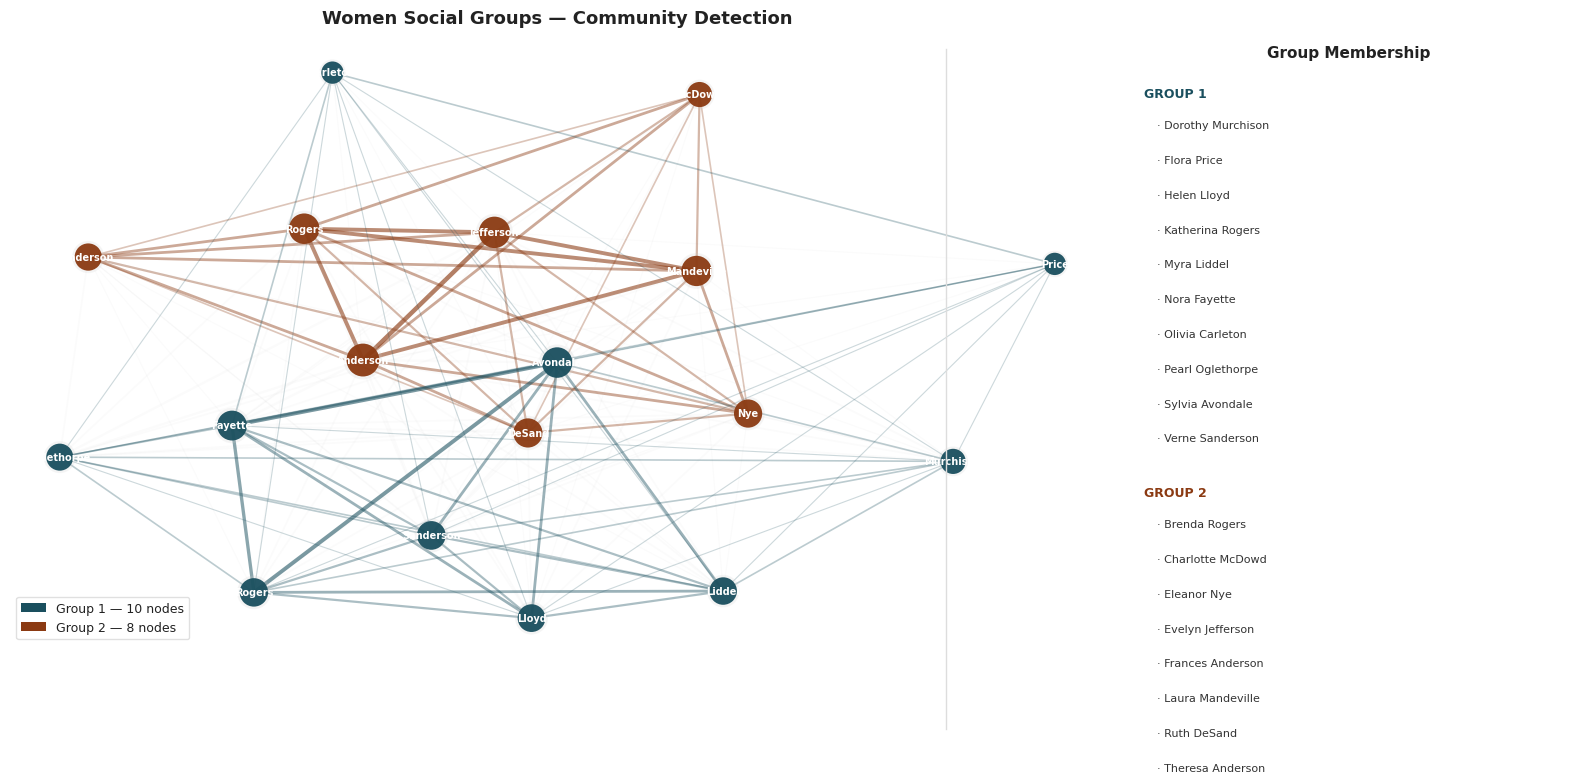

Saved: women_communities.png


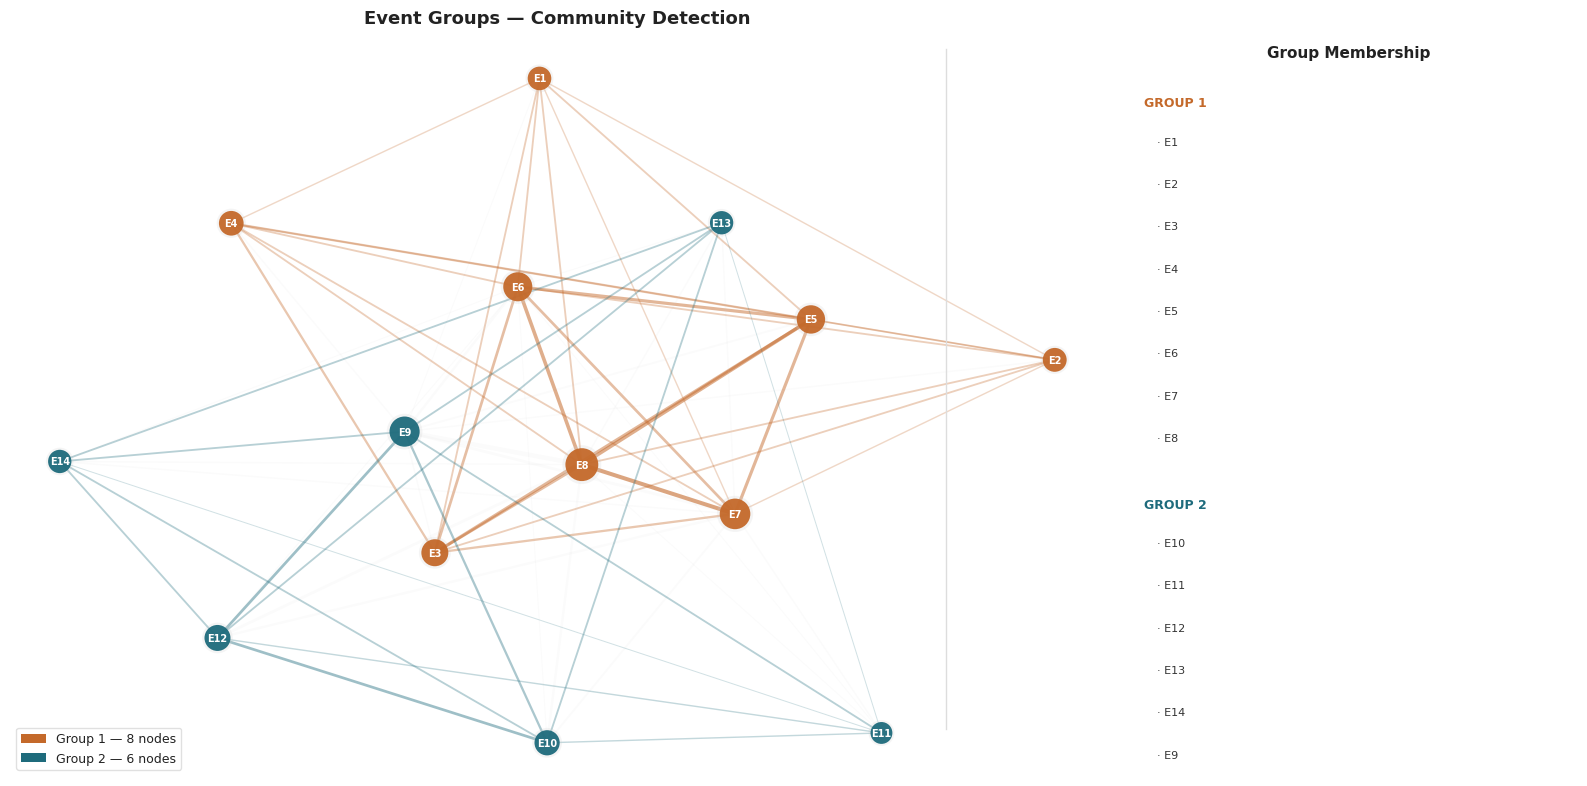

Saved: events_communities.png


In [26]:
def draw_community_plot(G_proj, communities, palette, title, filename, use_lastname=True):
    """Community network + membership table side by side."""
    weights = np.array([d['weight'] for _, _, d in G_proj.edges(data=True)])
    max_w   = weights.max()
    w_norm  = weights / max_w
    wdeg    = dict(G_proj.degree(weight='weight'))
    max_wd  = max(wdeg.values())
    pos     = nx.spring_layout(G_proj, weight='weight', seed=42, k=3.2)

    node_comm = {node: i for i, comm in enumerate(communities) for node in comm}

    fig, axes = plt.subplots(1, 2, figsize=(16, 8),
                             gridspec_kw={'width_ratios': [2.4, 1]})
    fig.patch.set_facecolor('white')

    ax = axes[0]
    ax.set_facecolor('white')

    for (u, v, d), wn in zip(G_proj.edges(data=True), w_norm):
        same = node_comm[u] == node_comm[v]
        x0, y0 = pos[u]; x1, y1 = pos[v]
        ax.plot([x0, x1], [y0, y1],
                color=palette[node_comm[u]] if same else '#CCCCCC',
                linewidth=0.4 + 2.8 * wn,
                alpha=(0.15 + 0.5 * wn) if same else 0.08,
                solid_capstyle='round')

    node_list   = list(G_proj.nodes())
    node_sizes  = [160 + 400 * (wdeg[n] / max_wd) for n in node_list]
    node_colors = [palette[node_comm[n]] for n in node_list]

    nx.draw_networkx_nodes(G_proj, pos, nodelist=node_list,
                           node_size=[s * 1.4 for s in node_sizes],
                           node_color='#CCCCCC', alpha=0.2, linewidths=0, ax=ax)
    nx.draw_networkx_nodes(G_proj, pos, nodelist=node_list,
                           node_size=node_sizes, node_color=node_colors,
                           alpha=0.95, linewidths=0, ax=ax)

    for node in node_list:
        x, y = pos[node]
        label = node.split()[-1] if use_lastname and ' ' in node else node
        ax.text(x, y, label, ha='center', va='center',
                fontsize=7, fontweight='bold', color='white')

    ax.legend(handles=[
        Patch(facecolor=palette[i], label=f'Group {i+1} — {len(communities[i])} nodes')
        for i in range(len(communities))
    ], loc='lower left', frameon=True, framealpha=0.9, edgecolor='#DDDDDD', fontsize=9)
    ax.set_title(title, pad=16)
    ax.axis('off')

    # Membership list panel
    ax2 = axes[1]
    ax2.set_facecolor('white')
    ax2.axis('off')
    ax2.text(0.5, 1.0, 'Group Membership', ha='center', va='top',
             fontsize=11, fontweight='bold', transform=ax2.transAxes)

    y_pos = 0.93
    for i, comm in enumerate(communities):
        ax2.text(0.05, y_pos, f'GROUP {i+1}', ha='left', va='top',
                 fontsize=9, fontweight='bold', color=palette[i], transform=ax2.transAxes)
        y_pos -= 0.055
        for name in sorted(comm):
            ax2.text(0.08, y_pos, f'· {name}', ha='left', va='top',
                     fontsize=8, color='#333333', transform=ax2.transAxes)
            y_pos -= 0.058
        y_pos -= 0.03

    fig.add_artist(plt.Line2D([0.595, 0.595], [0.08, 0.93],
                               transform=fig.transFigure, color='#DDDDDD', linewidth=1))
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    print(f'Saved: {filename}')


# Women communities — dark teal / dark amber (distinct from C_WOMEN/C_EVENTS)
draw_community_plot(W, communities_women,
                    palette={0: C_G1, 1: C_G2},
                    title='Women Social Groups — Community Detection',
                    filename='women_communities.png',
                    use_lastname=True)

# Events communities — light amber / light teal (distinct from C_WOMEN/C_EVENTS)
draw_community_plot(E, communities_events,
                    palette={0: C_EG1, 1: C_EG2},
                    title='Event Groups — Community Detection',
                    filename='events_communities.png',
                    use_lastname=False)

I included a few overall network measures to give context for the projections as a whole. That helps describe whether these are loose networks or tightly connected ones.

## 8. Network-Level Statistics

In [27]:
def network_stats(G_proj, label):
    print(f'=== {label} ===')
    print(f'  Nodes              : {G_proj.number_of_nodes()}')
    print(f'  Edges              : {G_proj.number_of_edges()}')
    print(f'  Density            : {nx.density(G_proj):.4f}')
    g = G_proj if nx.is_connected(G_proj) else G_proj.subgraph(
            max(nx.connected_components(G_proj), key=len))
    print(f'  Avg Shortest Path  : {nx.average_shortest_path_length(g):.4f}')
    print(f'  Diameter           : {nx.diameter(g)}')
    print(f'  Avg Clustering     : {nx.average_clustering(G_proj):.4f}')
    print(f'  Transitivity       : {nx.transitivity(G_proj):.4f}')
    print()

network_stats(W, 'Women Projection')
network_stats(E, 'Events Projection')

=== Women Projection ===
  Nodes              : 18
  Edges              : 139
  Density            : 0.9085
  Avg Shortest Path  : 1.0915
  Diameter           : 2
  Avg Clustering     : 0.9367
  Transitivity       : 0.9284

=== Events Projection ===
  Nodes              : 14
  Edges              : 66
  Density            : 0.7253
  Avg Shortest Path  : 1.2747
  Diameter           : 2
  Avg Clustering     : 0.9084
  Transitivity       : 0.8311



### WHY A HEATMAP AND WHY TWO MATRICES

The heatmap is the only place in the notebook where we show the full 18×14 attendance record directly, not through a derived network. The left matrix (women × events) is the raw biadjacency — it lets the reader verify the projections by eye and see which women attended which events. The right matrix (M @ M.T) is the co-attendance count between every pair of women, which is literally what the weighted women projection encodes as edge weights. Showing both together makes the bipartite→projection transformation transparent. Rows and columns are ordered by degree so the densest region appears in the top-left corner.

I wanted to include a matrix view because sometimes the overlap patterns are easier to see in a grid than in a graph. It gives a cleaner way to compare attendance and co-attendance across the full set of women and events.

## 9. Co-Attendance Matrix

*Encoding: cell color = attendance (left) or co-attendance count (right); both use palette-derived colormaps; rows/columns ordered by degree*

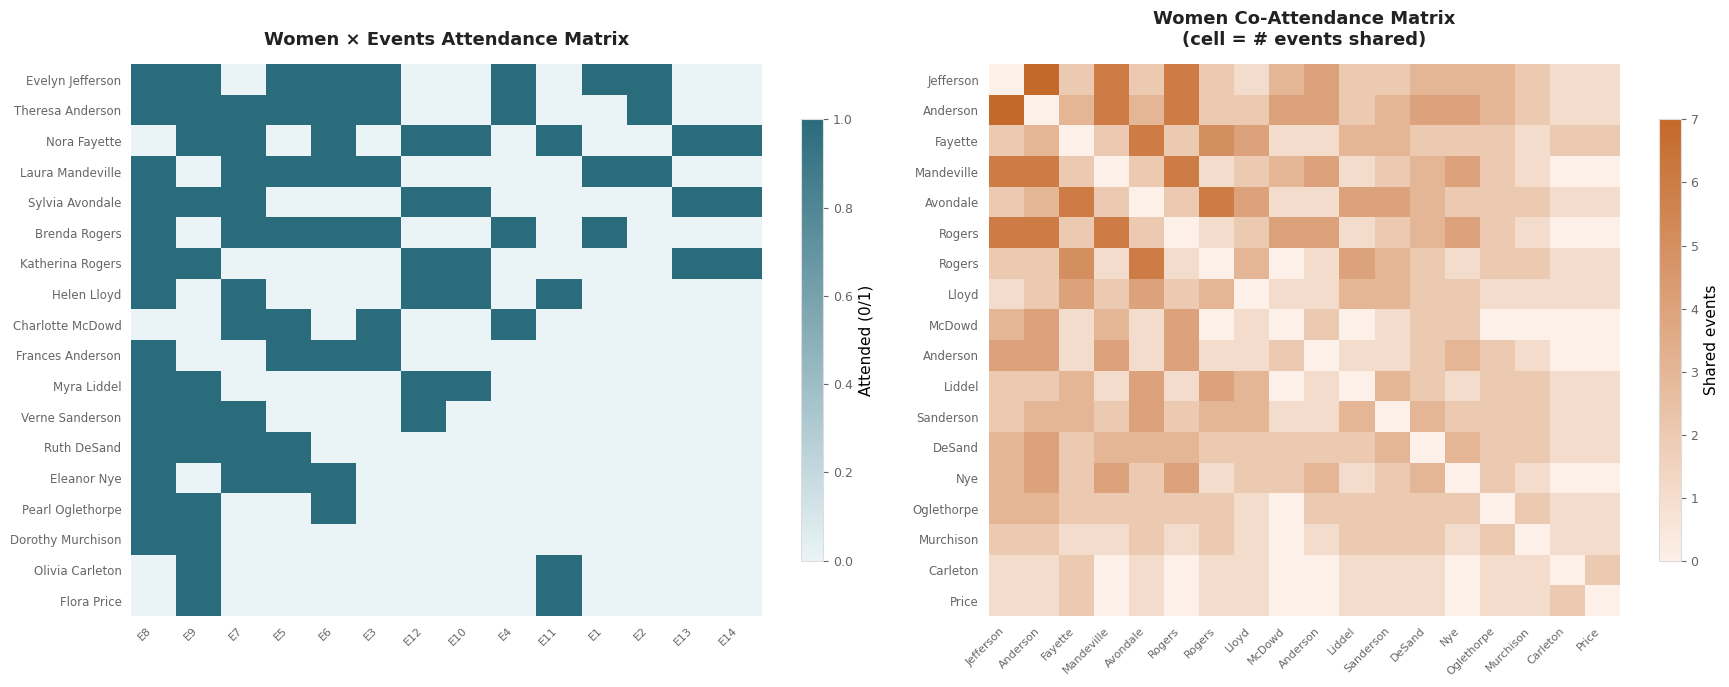

Saved: coattendance_matrix.png


In [28]:
# Order by degree for cleaner visual pattern
women_ord  = df_women.index.tolist()
events_ord = df_events.index.tolist()

biadj    = bipartite.biadjacency_matrix(G, row_order=women_ord, column_order=events_ord).toarray()
co_women = biadj @ biadj.T
np.fill_diagonal(co_women, 0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: attendance matrix — teal cmap
ax1 = axes[0]
im1 = ax1.imshow(biadj, cmap=CMAP_WOMEN, aspect='auto', vmin=0, vmax=1)
ax1.set_xticks(range(len(events_ord)))
ax1.set_xticklabels(events_ord, rotation=45, ha='right', fontsize=8)
ax1.set_yticks(range(len(women_ord)))
ax1.set_yticklabels(women_ord, fontsize=8.5)
ax1.set_title('Women × Events Attendance Matrix', fontweight='bold')
ax1.tick_params(bottom=False, left=False)
for spine in ax1.spines.values(): spine.set_visible(False)
plt.colorbar(im1, ax=ax1, shrink=0.8, label='Attended (0/1)')

# Right: co-attendance matrix — amber cmap
ax2 = axes[1]
im2 = ax2.imshow(co_women, cmap=CMAP_EVENTS, aspect='auto')
ax2.set_xticks(range(len(women_ord)))
ax2.set_xticklabels([w.split()[-1] for w in women_ord],  # last names only to reduce clutter
                    rotation=45, ha='right', fontsize=8)
ax2.set_yticks(range(len(women_ord)))
ax2.set_yticklabels([w.split()[-1] for w in women_ord], fontsize=8.5)
ax2.set_title('Women Co-Attendance Matrix\n(cell = # events shared)', fontweight='bold')
ax2.tick_params(bottom=False, left=False)
for spine in ax2.spines.values(): spine.set_visible(False)
plt.colorbar(im2, ax=ax2, shrink=0.8, label='Shared events')

plt.tight_layout()
plt.savefig('coattendance_matrix.png')
plt.show()
print('Saved: coattendance_matrix.png')

## 10. Key Findings & Interpretation

### 10.1 Relationships Between the Women

| Observation | Evidence | Interpretation |
|---|---|---|
| **Social hubs** | Evelyn Jefferson, Theresa Anderson, Nora Fayette each attended 8 events — highest in dataset | Central organizers; consistently appear alongside the most-connected women |
| **Top brokers (betweenness)** | Dorothy Murchison, Olivia Carleton, Flora Price have highest betweenness centrality | Bridge women connecting the two social groups; removing them would fragment the network |
| **Top prestige (eigenvector)** | Evelyn Jefferson, Theresa Anderson, Sylvia Avondale rank highest | Well-connected to other well-connected women — social prestige, not just raw attendance |
| **Two distinct groups** | Greedy modularity recovers 2 communities: Group 1 (10 women) and Group 2 (8 women) | Distinct social circles matching 1941 study findings; the two groups broadly align with earlier- versus later-event participation patterns |
| **High clustering (0.94)** | Near-complete triangle closure in projection | Tightly-knit clique structure — friends of friends are friends |
| **Compact network (diameter 2)** | Any two women reachable in at most 2 hops | The projection behaves like a tightly connected small social world — social influence spreads quickly across the group |

### 10.2 Relationships Between the Social Events

| Observation | Evidence | Interpretation |
|---|---|---|
| **Most central events** | E6, E7, E8, E9 have degree=1.0 and highest eigenvector centrality | Large gatherings attended by women from both social groups — community-wide events |
| **Top bridge events (betweenness)** | E6 has betweenness of 0.29 — far above all others | E6 is the single most critical bridge between early-season and late-season social clusters |
| **Two event clusters** | Group 1: E1–E8; Group 2: E9–E14 | The two event clusters broadly suggest an early/late seasonal split in social activity, though chronology is interpretive |
| **Strongest event pair** | E8 & E9 share 9 women — strongest overlap in dataset | Back-to-back events with near-identical attendance; likely consecutive in the social calendar |
| **Peripheral events** | E1, E2, E13, E14 each attended by only 3 women | Small, exclusive affairs — likely private gatherings for a specific sub-group |

### 10.3 Why This Dataset Remains Important

The Davis Southern Women dataset has been foundational in social network analysis because:
- It is one of the **earliest empirical bipartite social networks** with documented real-world meaning.
- It demonstrated that social structure — cliques, hierarchies, bridge roles — can be recovered **purely from attendance records**, without any self-reported friendship data.
- It continues to serve as a **benchmark** for bipartite projection, community detection, and centrality algorithms.
- The same analytic pattern (users × items, accounts × transactions, authors × papers) applies directly to modern web analytics and recommendation systems.

More broadly, this bipartite structure mirrors many web analytics settings: users interact with pages, products, or events, and projecting those interactions reveals hidden communities, central actors, and bridge structures that are not visible from raw interaction logs alone. The analytical moves made here — projection, centrality with corrected weights, community detection — transfer directly to modern recommendation systems, fraud detection, and social platform analysis.